In [1]:
from src.utils.config_loader import load_config
from src.utils.data_loader import DataLoader
from src.transform.eda import EDA
from src.transform.feature_engineering import FeatureEngineer
from src.training.tuner import Tuner
from src.training.trainer import Trainer
from src.evaluate.metrics import rmse

import numpy as np


In [2]:
#Load Data 

paths = load_config("config/paths.yaml")
schema = load_config("config/schema.yaml")
model_config = load_config("config/model.yaml")
loader = DataLoader(paths)

train = loader.load_train()
test = loader.load_test()



2026-06-01 22:09:03.269 | INFO     | src.utils.data_loader:_load:35 - Loading 'train' from data/train.csv
2026-06-01 22:09:03.361 | INFO     | src.utils.data_loader:_load:37 - Loaded 'train': shape=(54000, 15)
2026-06-01 22:09:03.363 | INFO     | src.utils.data_loader:_load:35 - Loading 'test' from data/test.csv
2026-06-01 22:09:03.427 | INFO     | src.utils.data_loader:_load:37 - Loaded 'test': shape=(36000, 14)


In [3]:
train = FeatureEngineer.extract_datetime_features(train)
train = FeatureEngineer.drop_text_columns(train)
train = FeatureEngineer.encode_categoricals(train)

2026-06-01 22:09:11.479 | INFO     | src.transform.feature_engineering:extract_datetime_features:29 - Datetime features extracted
2026-06-01 22:09:11.483 | INFO     | src.transform.feature_engineering:drop_text_columns:45 - Dropped text columns: ['ClaimDescription']
2026-06-01 22:09:11.489 | INFO     | src.transform.feature_engineering:encode_categoricals:67 - Categorical columns encoded


In [5]:
target = schema["target_column"]
cat_features = schema["features"]["categorical"]
num_features = schema["features"]["numerical"]
eda = EDA(train, target=target)


In [20]:
eda.summary()


2026-06-01 18:37:37.493 | INFO     | src.transform.eda:summary:33 - Summary computed for 17 columns


,dtype,null_count,null_pct,n_unique
ClaimNumber,str,0,0.00,54000
Age,int64,0,0.00,68
Gender,int64,0,0.00,3
MaritalStatus,float64,29,0.05,3
DependentChildren,int64,0,0.00,9
DependentsOther,int64,0,0.00,5
WeeklyWages,float64,0,0.00,13211
PartTimeFullTime,int64,0,0.00,2
HoursWorkedPerWeek,float64,0,0.00,424
DaysWorkedPerWeek,int64,0,0.00,7


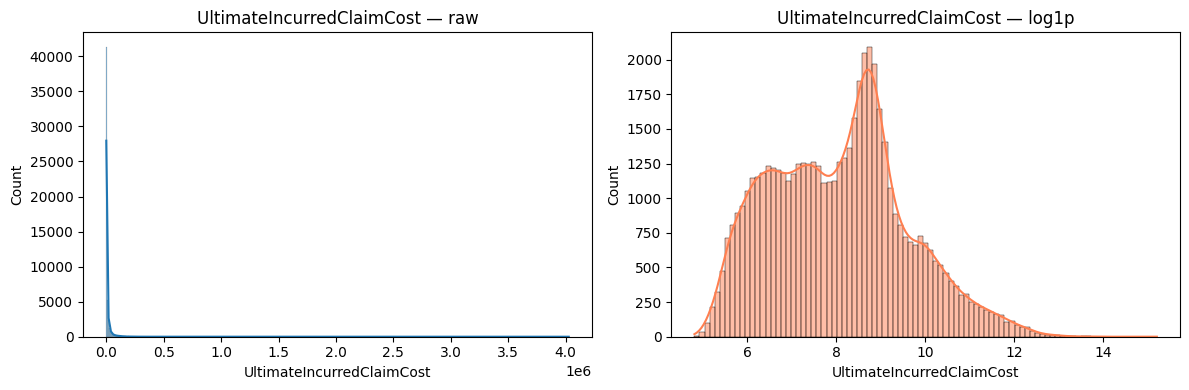

In [44]:
eda.target_distribution()


In [7]:
eda.missing_report()


2026-06-01 18:28:48.205 | INFO     | src.transform.eda:missing_report:66 - 1 columns with missing values


,null_pct
MaritalStatus,0.05


In [8]:
eda.cardinality_report()


,n_unique
ClaimNumber,54000
accident_month,12
report_month,12
accident_dayofweek,7


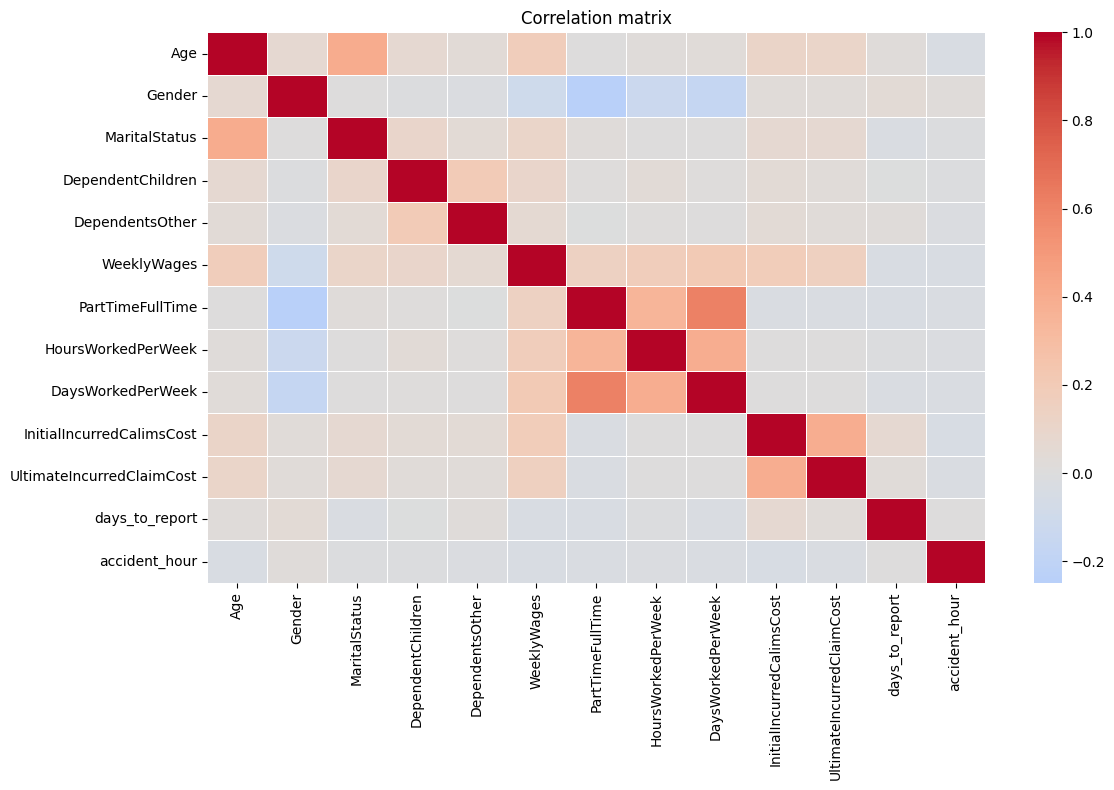

In [22]:
eda.correlation_matrix()


Gender


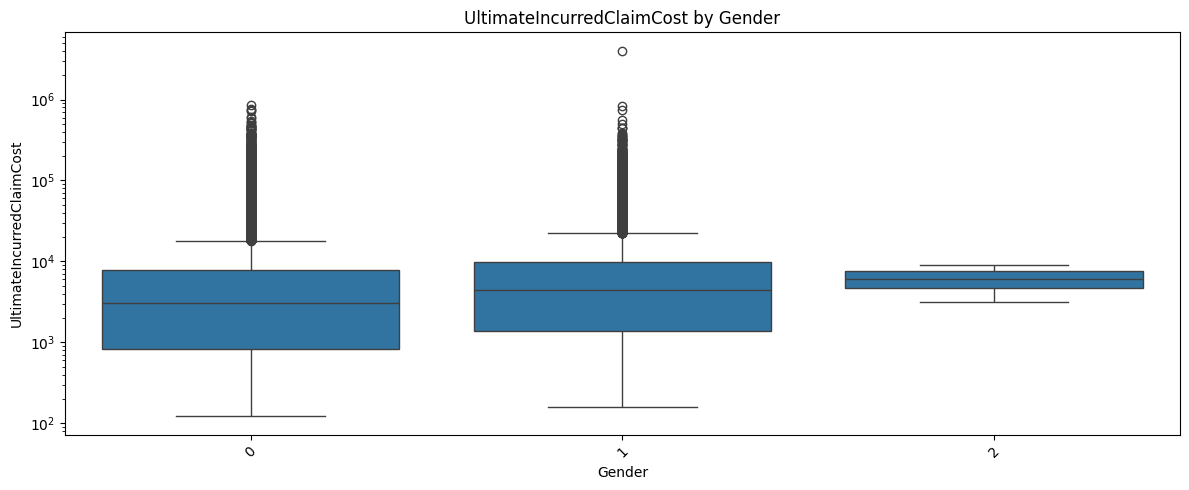

MaritalStatus


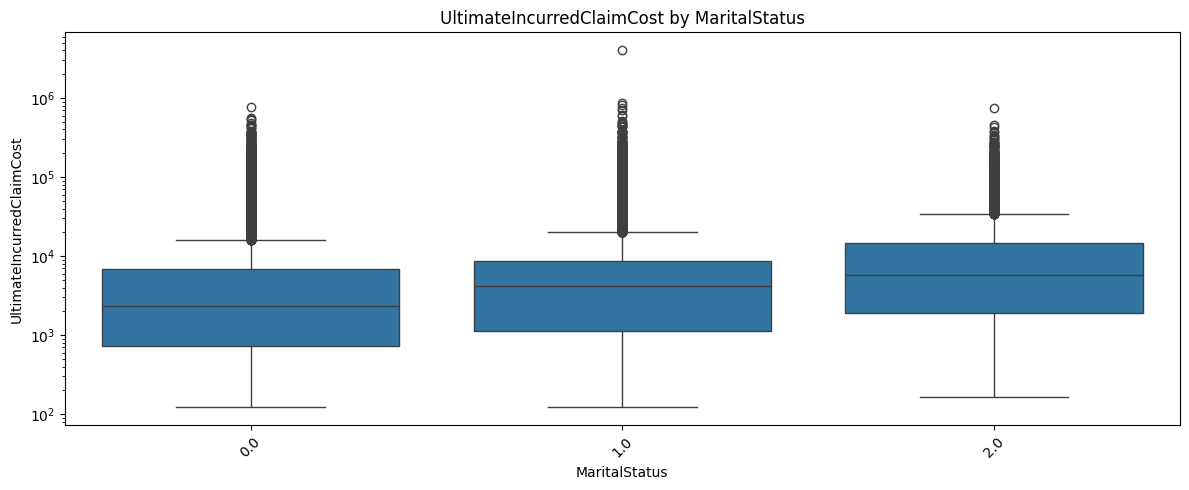

DependentChildren


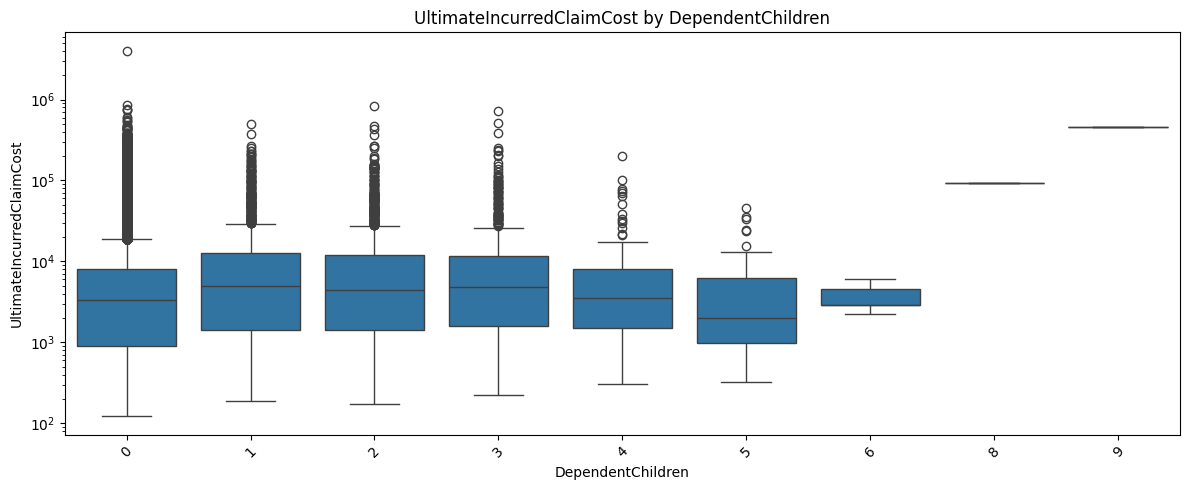

DependentsOther


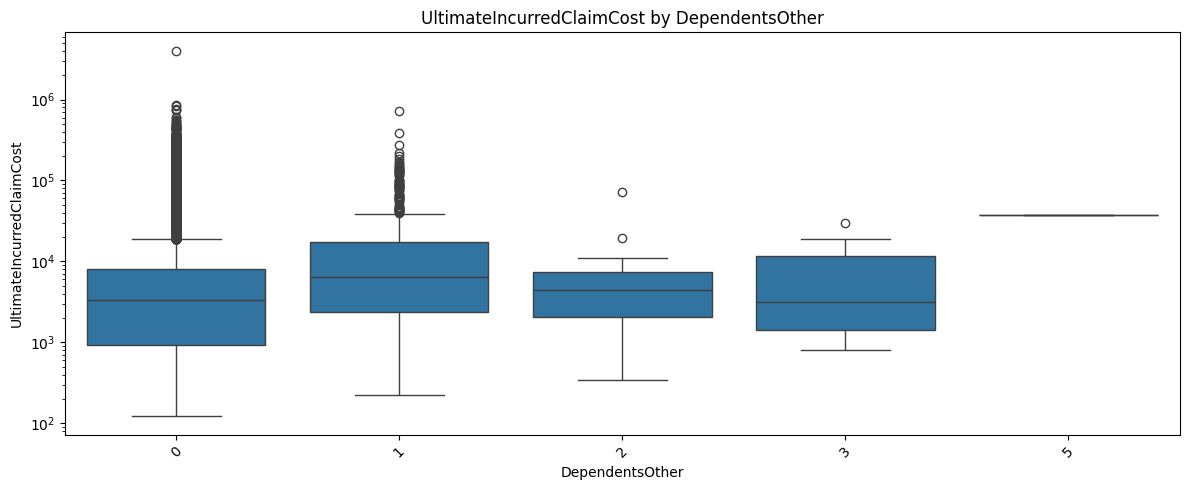

PartTimeFullTime


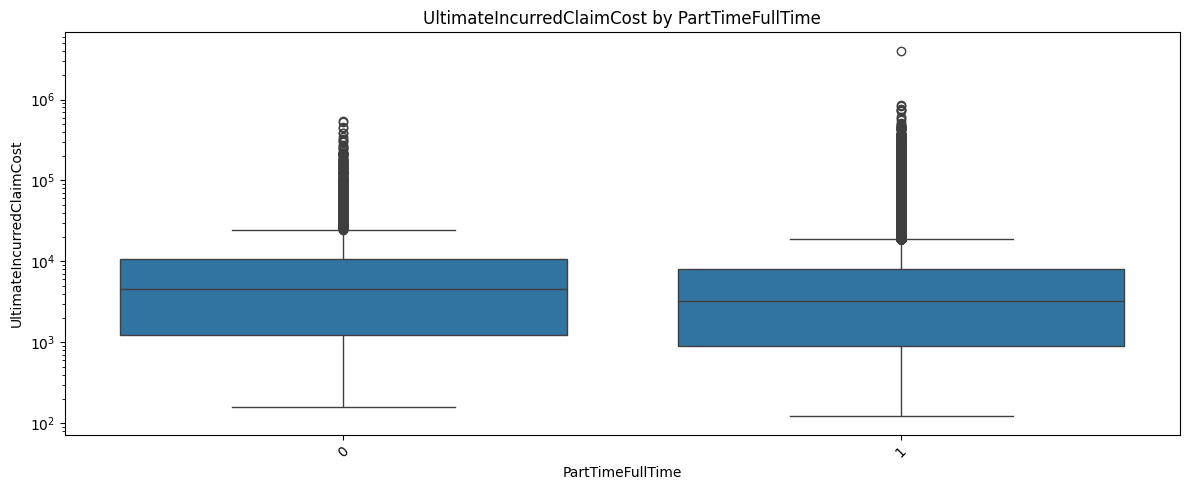

accident_month


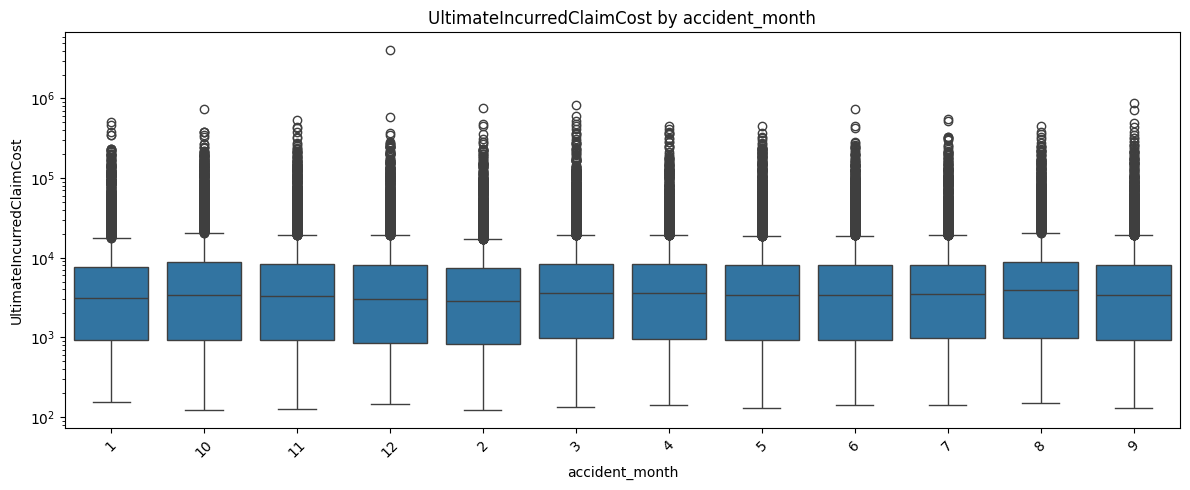

accident_dayofweek


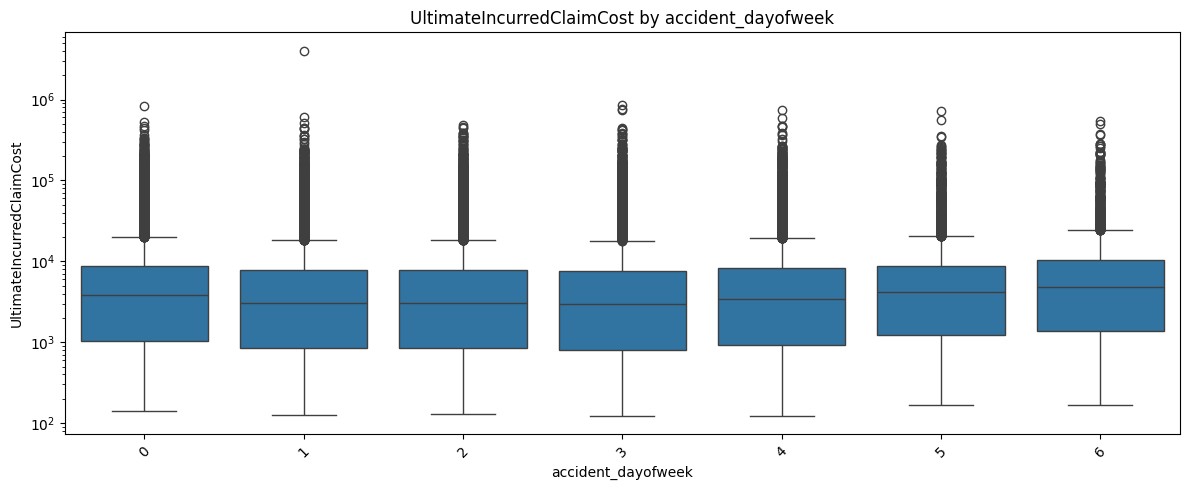

report_month


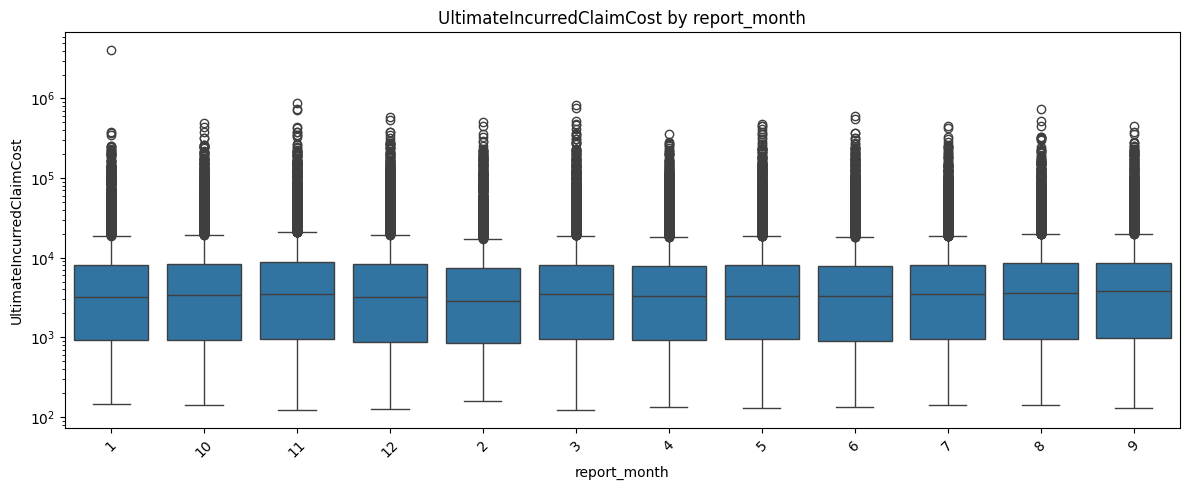

In [45]:
for col in cat_features:
    print(col)
    eda.categorical_vs_target(col)

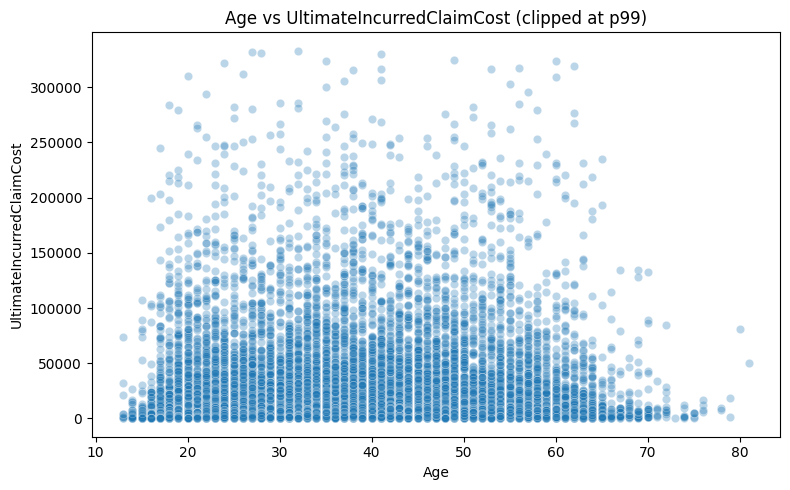

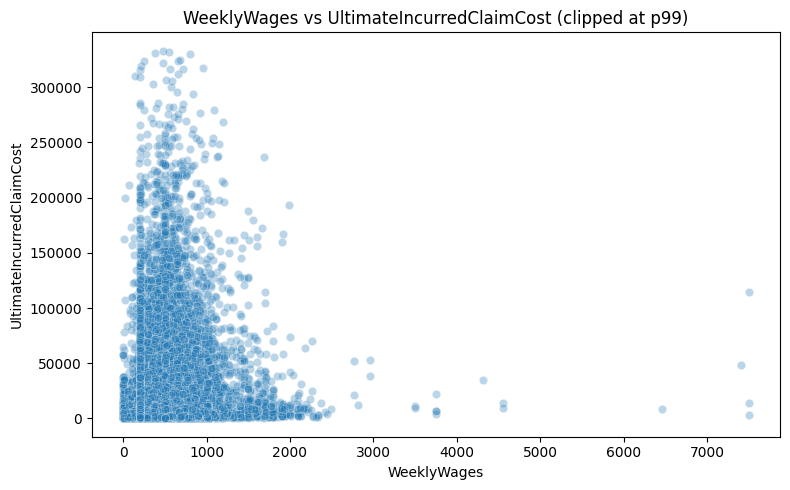

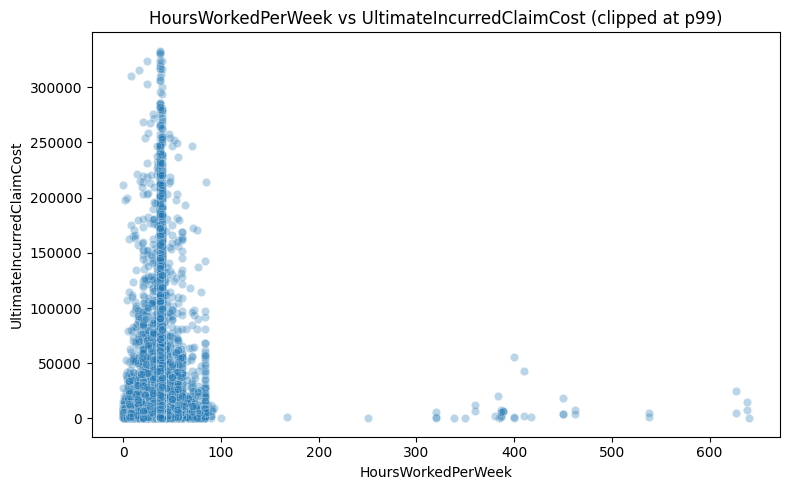

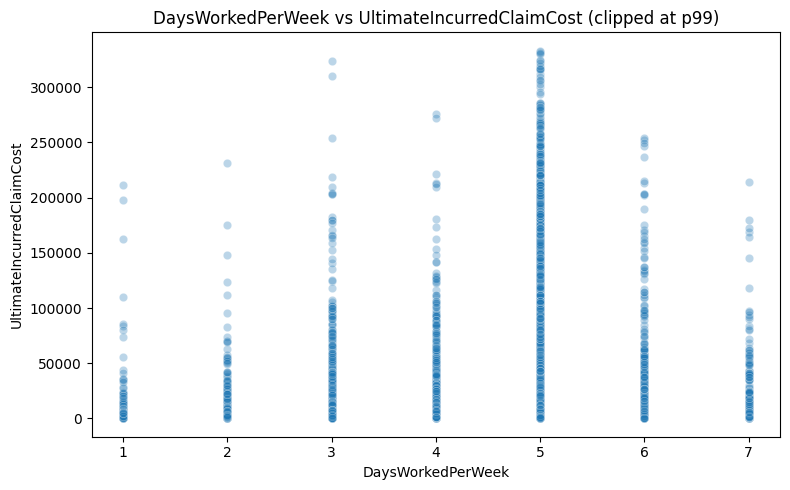

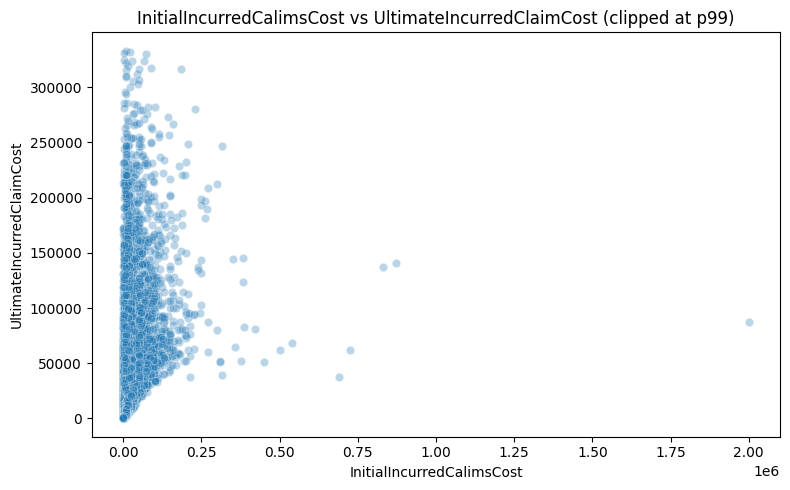

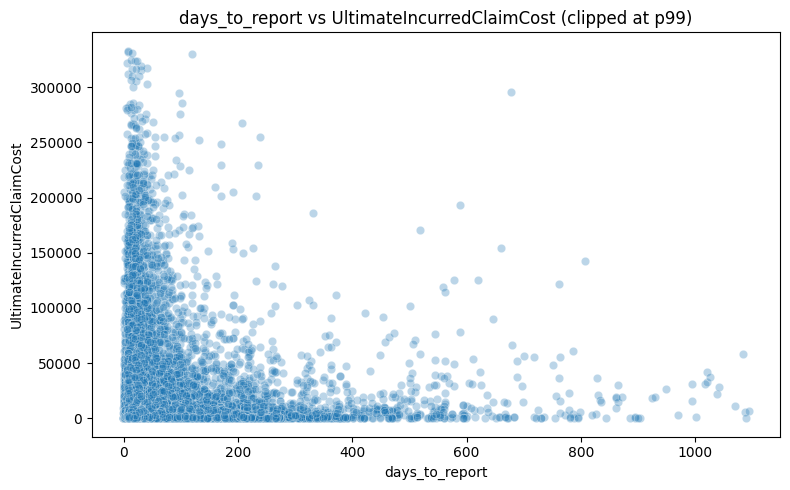

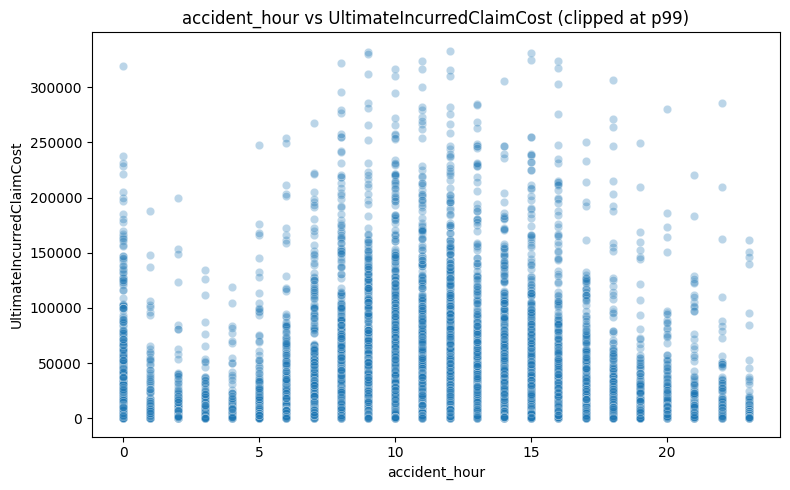

In [12]:

for col in num_features:
    eda.numerical_vs_target(df=train, col=col, target=target, clip_percentile=99.9)

In [43]:
train.head()

,ClaimNumber,Age,Gender,MaritalStatus,DependentChildren,DependentsOther,WeeklyWages,PartTimeFullTime,HoursWorkedPerWeek,DaysWorkedPerWeek,InitialIncurredCalimsCost,UltimateIncurredClaimCost,days_to_report,accident_month,accident_dayofweek,accident_hour,report_month
0,WC8285054,48,M,M,0,0,500.00,F,38.0,5,1500,4748.203388,86,4,1,7,7
1,WC6982224,43,F,M,0,0,509.34,F,37.5,5,5500,6326.285819,12,1,3,11,1
2,WC5481426,30,M,U,0,0,709.10,F,38.0,5,1700,2293.949087,20,3,0,0,4
3,WC9775968,41,M,S,0,0,555.46,F,38.0,5,15000,17786.487170,29,6,2,13,7
4,WC2634037,36,M,M,0,0,377.10,F,38.0,5,2800,4014.002925,28,8,2,8,9
